<a href="https://colab.research.google.com/github/hifsakazmi/cross-dataset-stress-detection/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Visualising signals across the three datasets

One representative subject per dataset, all six E4 signals on a shared time axis,
stress / non-stress phases shaded behind the traces. The visual story:
lab protocols (Campanella, WESAD) are densely labeled with clean rectangular phases,
the nurse data is mostly unlabeled with sparse stress events floating in a long
session.

**Subjects shown:**
- Campanella: `subject_01`
- WESAD: `S2`
- Nurse: session `83_1604630543` (nurse 83, ~4.4 hr session, two labeled phases)

**Signals shown raw** — TEMP warmup spike in WESAD and BVP zero-padding in Campanella
are deliberately visible to motivate the preprocessing step.

**Prereq:** run `00_setup.ipynb` first.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
if os.path.exists('/content/cross-dataset-stress-detection'):
    shutil.rmtree('/content/cross-dataset-stress-detection')
!git clone https://github.com/hifsakazmi/cross-dataset-stress-detection.git
%cd /content/cross-dataset-stress-detection

# Re-symlink data_extracted to Drive (the extraction itself doesn't need to re-run)
DRIVE_EXTRACTED = "/content/drive/MyDrive/stress_data/extracted"
if os.path.exists("data_extracted") or os.path.islink("data_extracted"):
    if os.path.islink("data_extracted"):
        os.unlink("data_extracted")
    else:
        shutil.rmtree("data_extracted")
os.symlink(DRIVE_EXTRACTED, "data_extracted")

!pip install -q -r requirements.txt

Mounted at /content/drive
Cloning into 'cross-dataset-stress-detection'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 150 (delta 36), reused 113 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 33.17 KiB | 3.01 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/cross-dataset-stress-detection
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4

In [4]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import src.data_loader as data_loader
import src.labeling as labeling
importlib.reload(data_loader)
importlib.reload(labeling)

from src.data_loader import load_subject
from src.labeling import get_campanella_labels, get_wesad_labels

DATA_ROOT = "data_extracted"
LABELS_ROOT = "labels"

# Subjects picked for the figure
CAMPANELLA_SUBJECT = "subject_01"
WESAD_SUBJECT = "S2"
NURSE_SESSION = "83_1604630543"

# Visual style: stress = red, non-stress = green, unlabeled = nothing
PHASE_COLORS = {0: "#4caf50", 1: "#e53935"}  # 0=non-stress, 1=stress
PHASE_ALPHA = 0.15

# Signal colors (one per signal, kept consistent across panels)
SIGNAL_COLORS = {
    "ACC":  "#5e35b1",
    "BVP":  "#1e88e5",
    "EDA":  "#fb8c00",
    "HR":   "#d81b60",
    "IBI":  "#00897b",
    "TEMP": "#6d4c41",
}

# Y-axis labels with units
SIGNAL_YLABELS = {
    "ACC":  "|ACC| (g)",
    "BVP":  "BVP",
    "EDA":  "EDA (\u03bcS)",
    "HR":   "HR (bpm)",
    "IBI":  "IBI (s)",
    "TEMP": "TEMP (\u00b0C)",
}

# Order the signals top-to-bottom in each panel
SIGNAL_ORDER = ["ACC", "BVP", "EDA", "HR", "IBI", "TEMP"]

## Load the three subjects and their labels

Phases come from three different sources:
- Campanella: computed from protocol timing
- WESAD: pre-extracted CSV in `labels/wesad/`
- Nurse: pre-extracted CSV in `labels/nurse/`

In [5]:
def load_nurse_labels(session_id, labels_root=LABELS_ROOT):
    """Load pre-extracted nurse phases as (start_sec, end_sec, label) tuples."""
    df = pd.read_csv(Path(labels_root) / "nurse" / f"{session_id}.csv")
    return list(df.itertuples(index=False, name=None))


def get_duration_sec(signals):
    """Recording duration in seconds, computed from the shortest signal."""
    return min(
        (sig.index[-1] - sig.index[0]).total_seconds()
        for sig in signals.values() if len(sig) > 0
    )


# Campanella
camp_signals, _ = load_subject("campanella", CAMPANELLA_SUBJECT, data_root=DATA_ROOT)
camp_duration = get_duration_sec(camp_signals)
camp_phases = get_campanella_labels(camp_duration)
print(f"Campanella {CAMPANELLA_SUBJECT}: {camp_duration/60:.1f} min, "
      f"{len(camp_phases)} phases")

# WESAD
wesad_signals, _ = load_subject("wesad", WESAD_SUBJECT, data_root=DATA_ROOT)
wesad_duration = get_duration_sec(wesad_signals)
wesad_phases = get_wesad_labels(WESAD_SUBJECT)
print(f"WESAD {WESAD_SUBJECT}: {wesad_duration/60:.1f} min, "
      f"{len(wesad_phases)} phases")

# Nurse
nurse_signals, _ = load_subject("nurse", NURSE_SESSION, data_root=DATA_ROOT)
nurse_duration = get_duration_sec(nurse_signals)
nurse_phases = load_nurse_labels(NURSE_SESSION)
print(f"Nurse {NURSE_SESSION}: {nurse_duration/60:.1f} min, "
      f"{len(nurse_phases)} phases")

  Loaded subject_01: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
Campanella subject_01: 41.2 min, 11 phases
  Loaded S2: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
WESAD S2: 130.7 min, 2 phases
  Loaded 83_1604630543: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
Nurse 83_1604630543: 266.6 min, 2 phases


## Plotting helpers

Two helpers:
- `signal_to_xy(df, signal_name)` — converts a signal DataFrame to (time_minutes, values).
  Handles ACC (3 axes → magnitude) and IBI (irregular sampling → use the offset column).
- `plot_dataset_panel(ax_row, signals, phases, duration, title)` — fills one row of
  6 subplots with shading + traces.

In [6]:
def signal_to_xy(df, signal_name):
    """
    Convert a signal DataFrame to (time_minutes_from_start, values).

    - ACC has 3 columns (x, y, z) -> return magnitude sqrt(x^2+y^2+z^2)
    - IBI is irregular -> use its time index as-is (already datetime)
    - Everything else is single-column
    """
    t0 = df.index[0]
    times_min = (df.index - t0).total_seconds() / 60

    if signal_name == "ACC":
        vals = np.sqrt((df.values.astype(float) ** 2).sum(axis=1)) / 64.0
        # E4 ACC is in 1/64 g units; divide by 64 to get g
    elif signal_name == "IBI":
        # df has columns ['offset', 'ibi'] — we want ibi as the value
        if "ibi" in df.columns:
            vals = df["ibi"].values.astype(float)
        else:
            vals = df.iloc[:, -1].values.astype(float)
    else:
        vals = df.iloc[:, 0].values.astype(float)

    return times_min.values, vals


def shade_phases(ax, phases, total_duration_sec):
    """Shade phase regions on a single axis. Times are converted to minutes."""
    for start_sec, end_sec, label in phases:
        color = PHASE_COLORS.get(label)
        if color is None:
            continue
        ax.axvspan(start_sec / 60, end_sec / 60,
                   color=color, alpha=PHASE_ALPHA, zorder=0)


def plot_dataset_panel(ax_row, signals, phases, duration_sec, dataset_title):
    """
    Fill one row of axes (6 subplots) with the 6 signals for one dataset.

    ax_row: 1D array of 6 Axes, left-to-right matches SIGNAL_ORDER
    """
    for ax, sig_name in zip(ax_row, SIGNAL_ORDER):
        if sig_name not in signals:
            ax.text(0.5, 0.5, f"{sig_name}\nnot available",
                    ha="center", va="center", transform=ax.transAxes,
                    color="grey", fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        df = signals[sig_name]
        if len(df) == 0:
            ax.text(0.5, 0.5, f"{sig_name}\nempty", ha="center", va="center",
                    transform=ax.transAxes, color="grey", fontsize=9)
            continue

        # Shade phases first (behind the trace)
        shade_phases(ax, phases, duration_sec)

        # Plot signal
        times_min, vals = signal_to_xy(df, sig_name)
        if sig_name == "IBI":
            ax.scatter(times_min, vals, s=3,
                       color=SIGNAL_COLORS[sig_name], alpha=0.6)
        else:
            ax.plot(times_min, vals,
                    color=SIGNAL_COLORS[sig_name], linewidth=0.6)

        ax.set_ylabel(SIGNAL_YLABELS[sig_name], fontsize=9)
        ax.set_xlim(0, duration_sec / 60)
        ax.tick_params(axis="both", labelsize=8)
        ax.grid(True, alpha=0.2, linewidth=0.5)

    # Dataset label on the leftmost axis
    ax_row[0].annotate(
        dataset_title,
        xy=(-0.35, 0.5), xycoords="axes fraction",
        ha="center", va="center",
        fontsize=12, fontweight="bold", rotation=90,
    )

## Visualising the six E4 signals per dataset

/tmp/ipykernel_10784/1071151487.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 1, 0.95])


Saved: results/fig1_signal_panel.png and .pdf


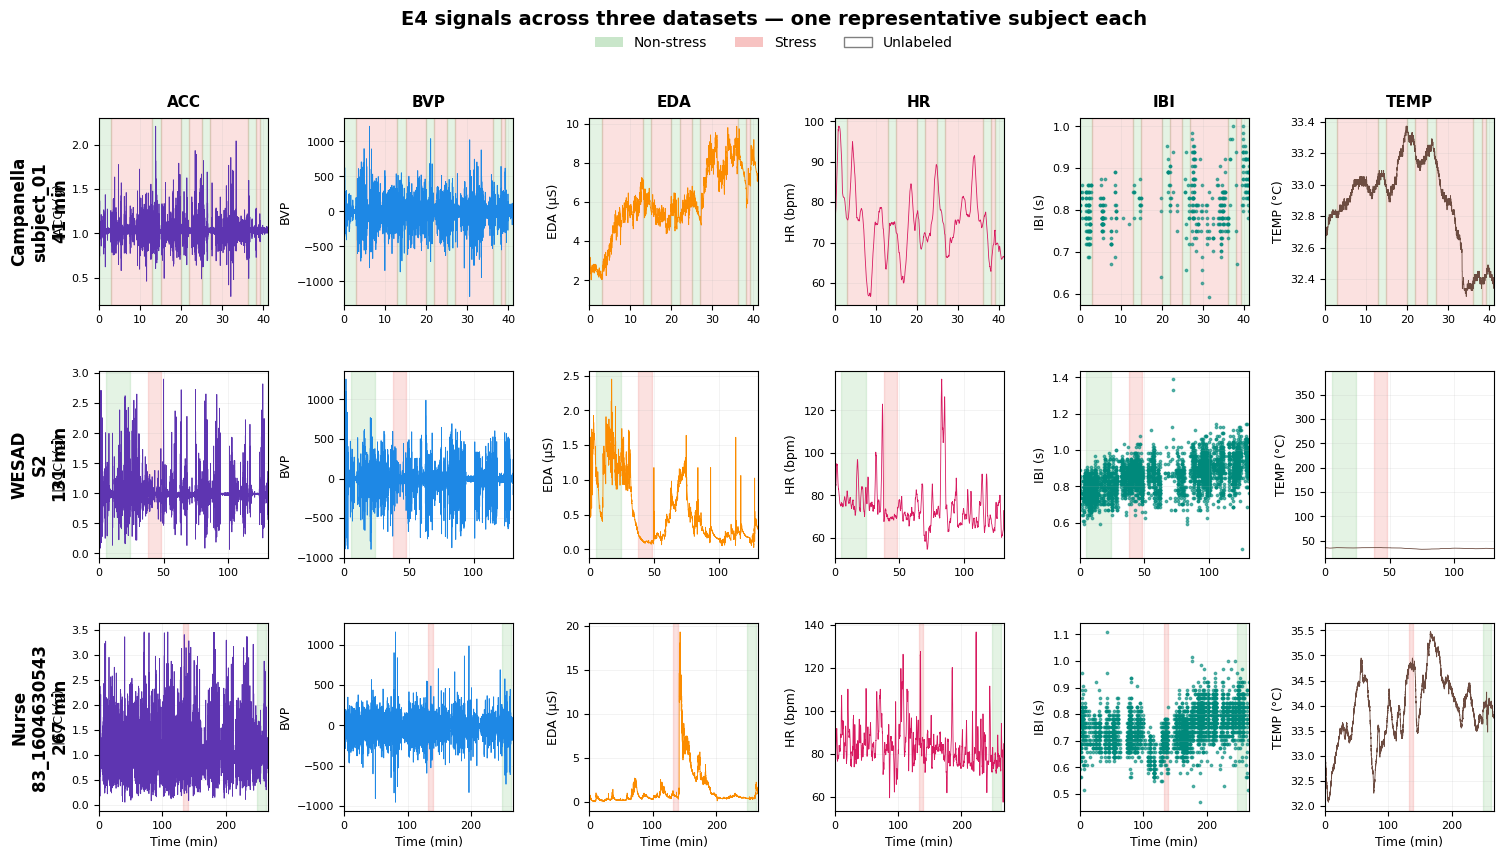

In [8]:
RESULTS_DIR = Path("/content/drive/MyDrive/stress_data/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    nrows=3, ncols=6,
    figsize=(18, 9),
    gridspec_kw={"hspace": 0.35, "wspace": 0.45},
)

plot_dataset_panel(
    axes[0], camp_signals, camp_phases, camp_duration,
    f"Campanella\n{CAMPANELLA_SUBJECT}\n{camp_duration/60:.0f} min",
)
plot_dataset_panel(
    axes[1], wesad_signals, wesad_phases, wesad_duration,
    f"WESAD\n{WESAD_SUBJECT}\n{wesad_duration/60:.0f} min",
)
plot_dataset_panel(
    axes[2], nurse_signals, nurse_phases, nurse_duration,
    f"Nurse\n{NURSE_SESSION}\n{nurse_duration/60:.0f} min",
)

# Column titles: signal names across the top
for ax, sig_name in zip(axes[0], SIGNAL_ORDER):
    ax.set_title(sig_name, fontsize=11, fontweight="bold", pad=8)

# X-axis label only on the bottom row
for ax in axes[2]:
    ax.set_xlabel("Time (min)", fontsize=9)

# Legend for phase colors
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=PHASE_COLORS[0], alpha=PHASE_ALPHA * 2,
          label="Non-stress"),
    Patch(facecolor=PHASE_COLORS[1], alpha=PHASE_ALPHA * 2,
          label="Stress"),
    Patch(facecolor="white", edgecolor="grey",
          label="Unlabeled"),
]
fig.legend(handles=legend_handles, loc="upper center",
           bbox_to_anchor=(0.5, 0.985), ncol=3, fontsize=10,
           frameon=False)

fig.suptitle(
    "E4 signals across three datasets — one representative subject each",
    fontsize=14, fontweight="bold", y=1.00,
)

plt.tight_layout(rect=[0.02, 0, 1, 0.95])

# Save as both PNG (for slides) and PDF (for the paper).
Path("results").mkdir(exist_ok=True)
fig.savefig(RESULTS_DIR / "fig1_signal_panel.png", dpi=200, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "fig1_signal_panel.pdf", bbox_inches="tight")
print("Saved: results/fig1_signal_panel.png and .pdf")

plt.show()

## Notes

**Campanella (top row)** — Clean alternating rest/task pattern. The BVP panel
starts with a brief flat segment (device warmup, zero-padded), HR ramps from 0
for the same reason, and the protocol's rectangular phases match the signal
responses visibly (HR climbs during task periods, EDA shows arousal spikes).

**WESAD (middle row)** — Two labeled phases: baseline and stress. The TEMP
panel shows the warmup spike near t=0 noted in the project context. EDA shows
the clearest contrast — much higher during the stress phase. Long unlabeled
regions correspond to amusement / meditation conditions that we dropped to
match the binary protocol of the other two datasets.

**Nurse (bottom row)** — The story. ~4 hours of recording, two small labeled
blocks (one stress around 130 min, one non-stress around 250 min) floating in
a sea of unlabeled time. This is what real-world stress labeling looks like
compared to a lab protocol.